## Feature correlation, Sequential Feature Selection and all 1 feature models

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier

%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

import pandas as pd

pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [3]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

### Feature correlation

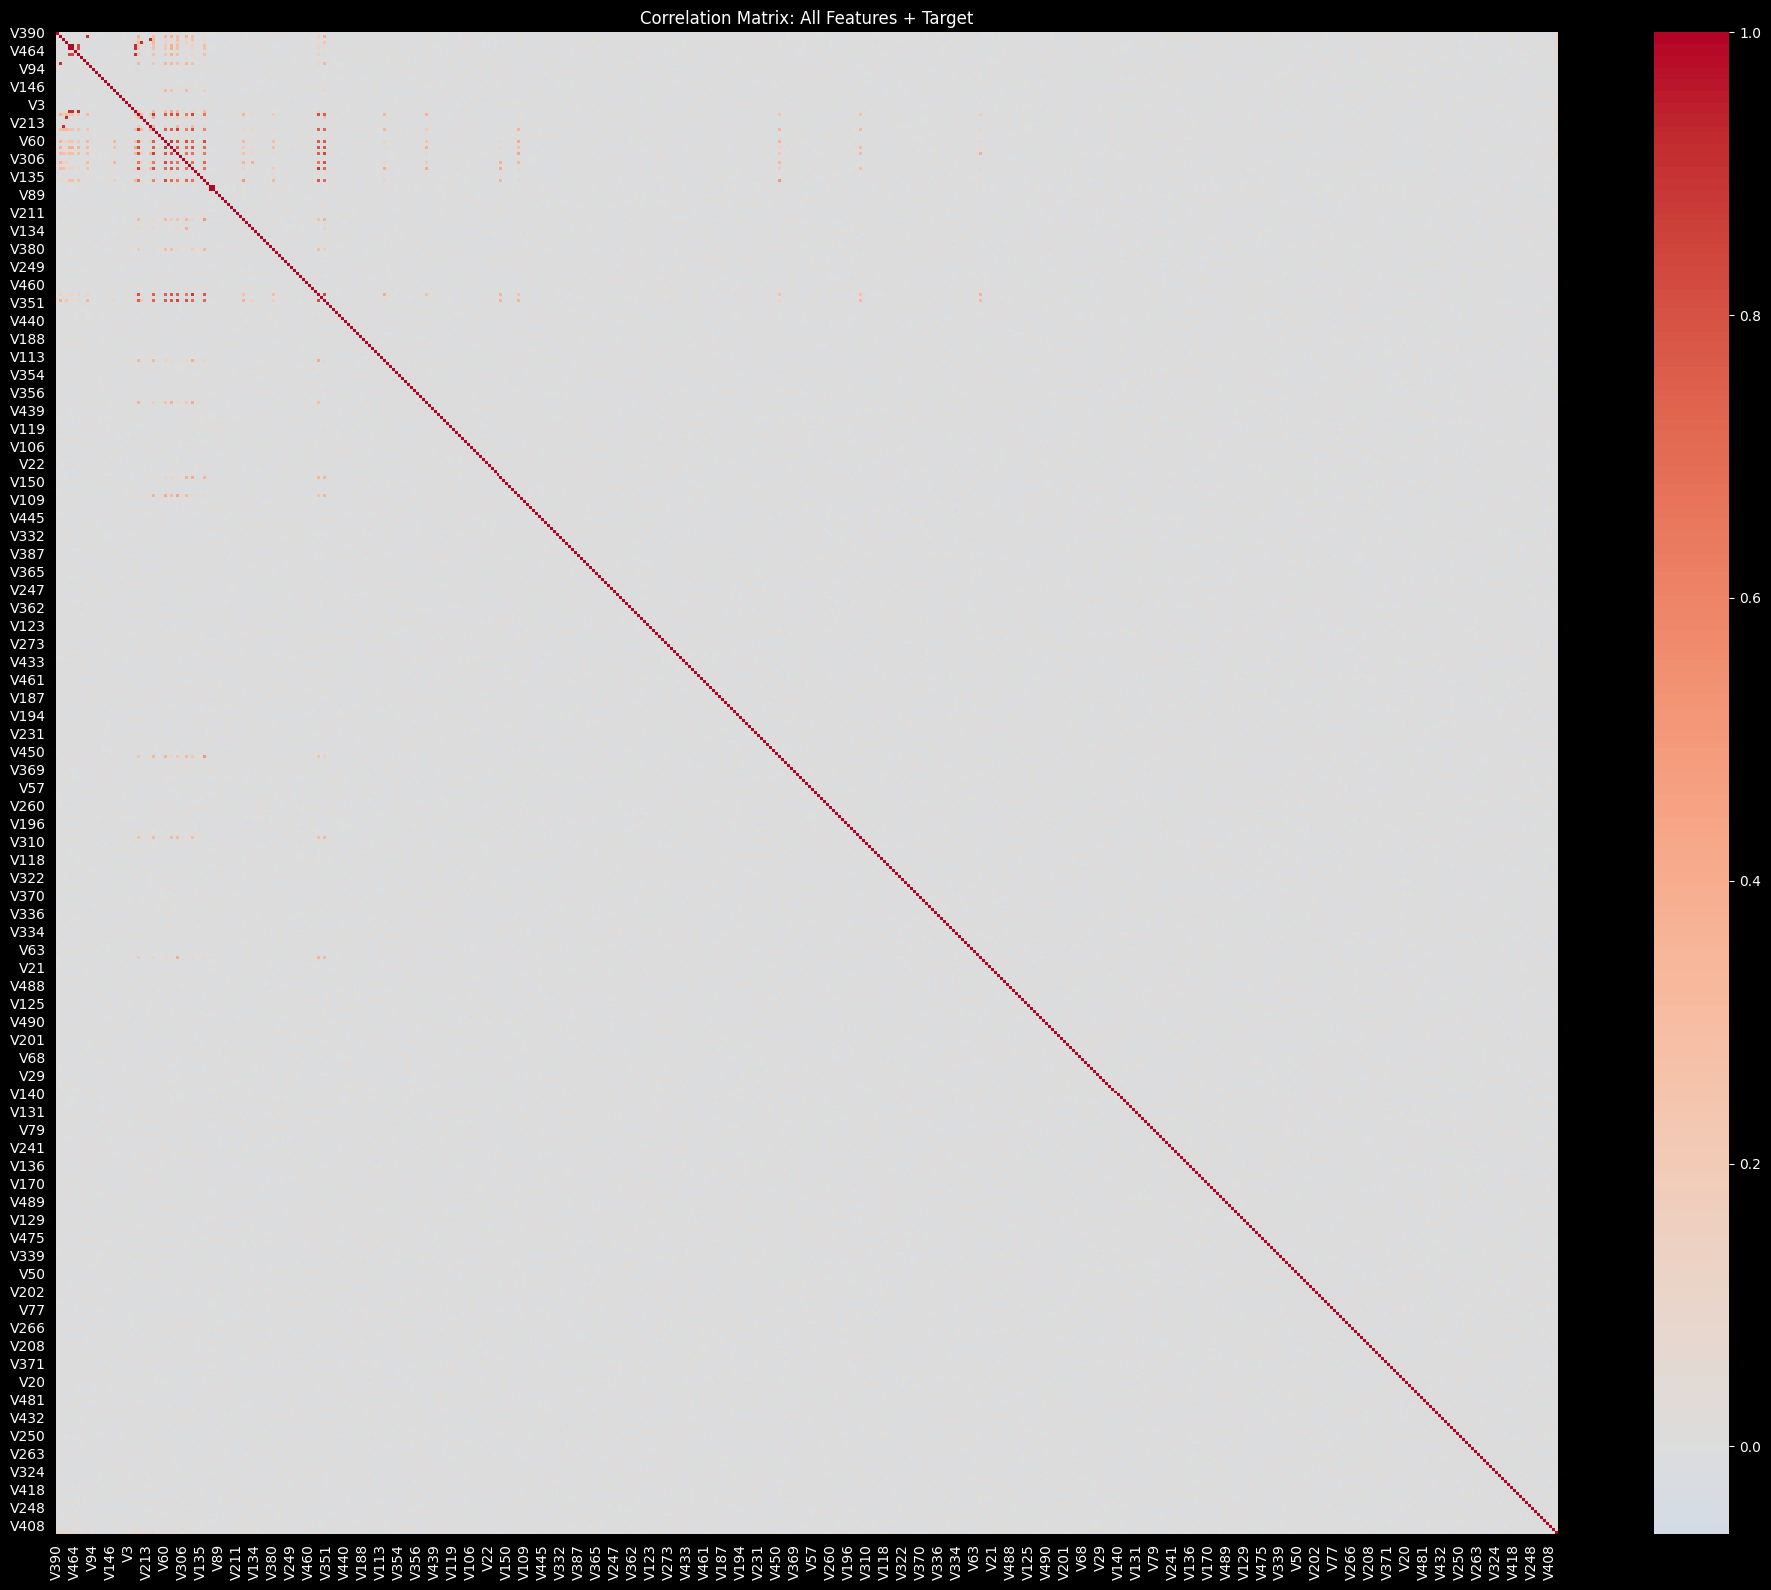

In [4]:
sorted_features = (
    feature_importance_df
    .sort_values("avg_normalized_rank")["feature"].tolist()
)
X_sorted = x_train_scaled[sorted_features]

corr_df = X_sorted.copy()
corr_df["target"] = y_train.values
corr_matrix = corr_df.corr(method="pearson")

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix: All Features + Target")
plt.tight_layout()
plt.show()

(101, 101)


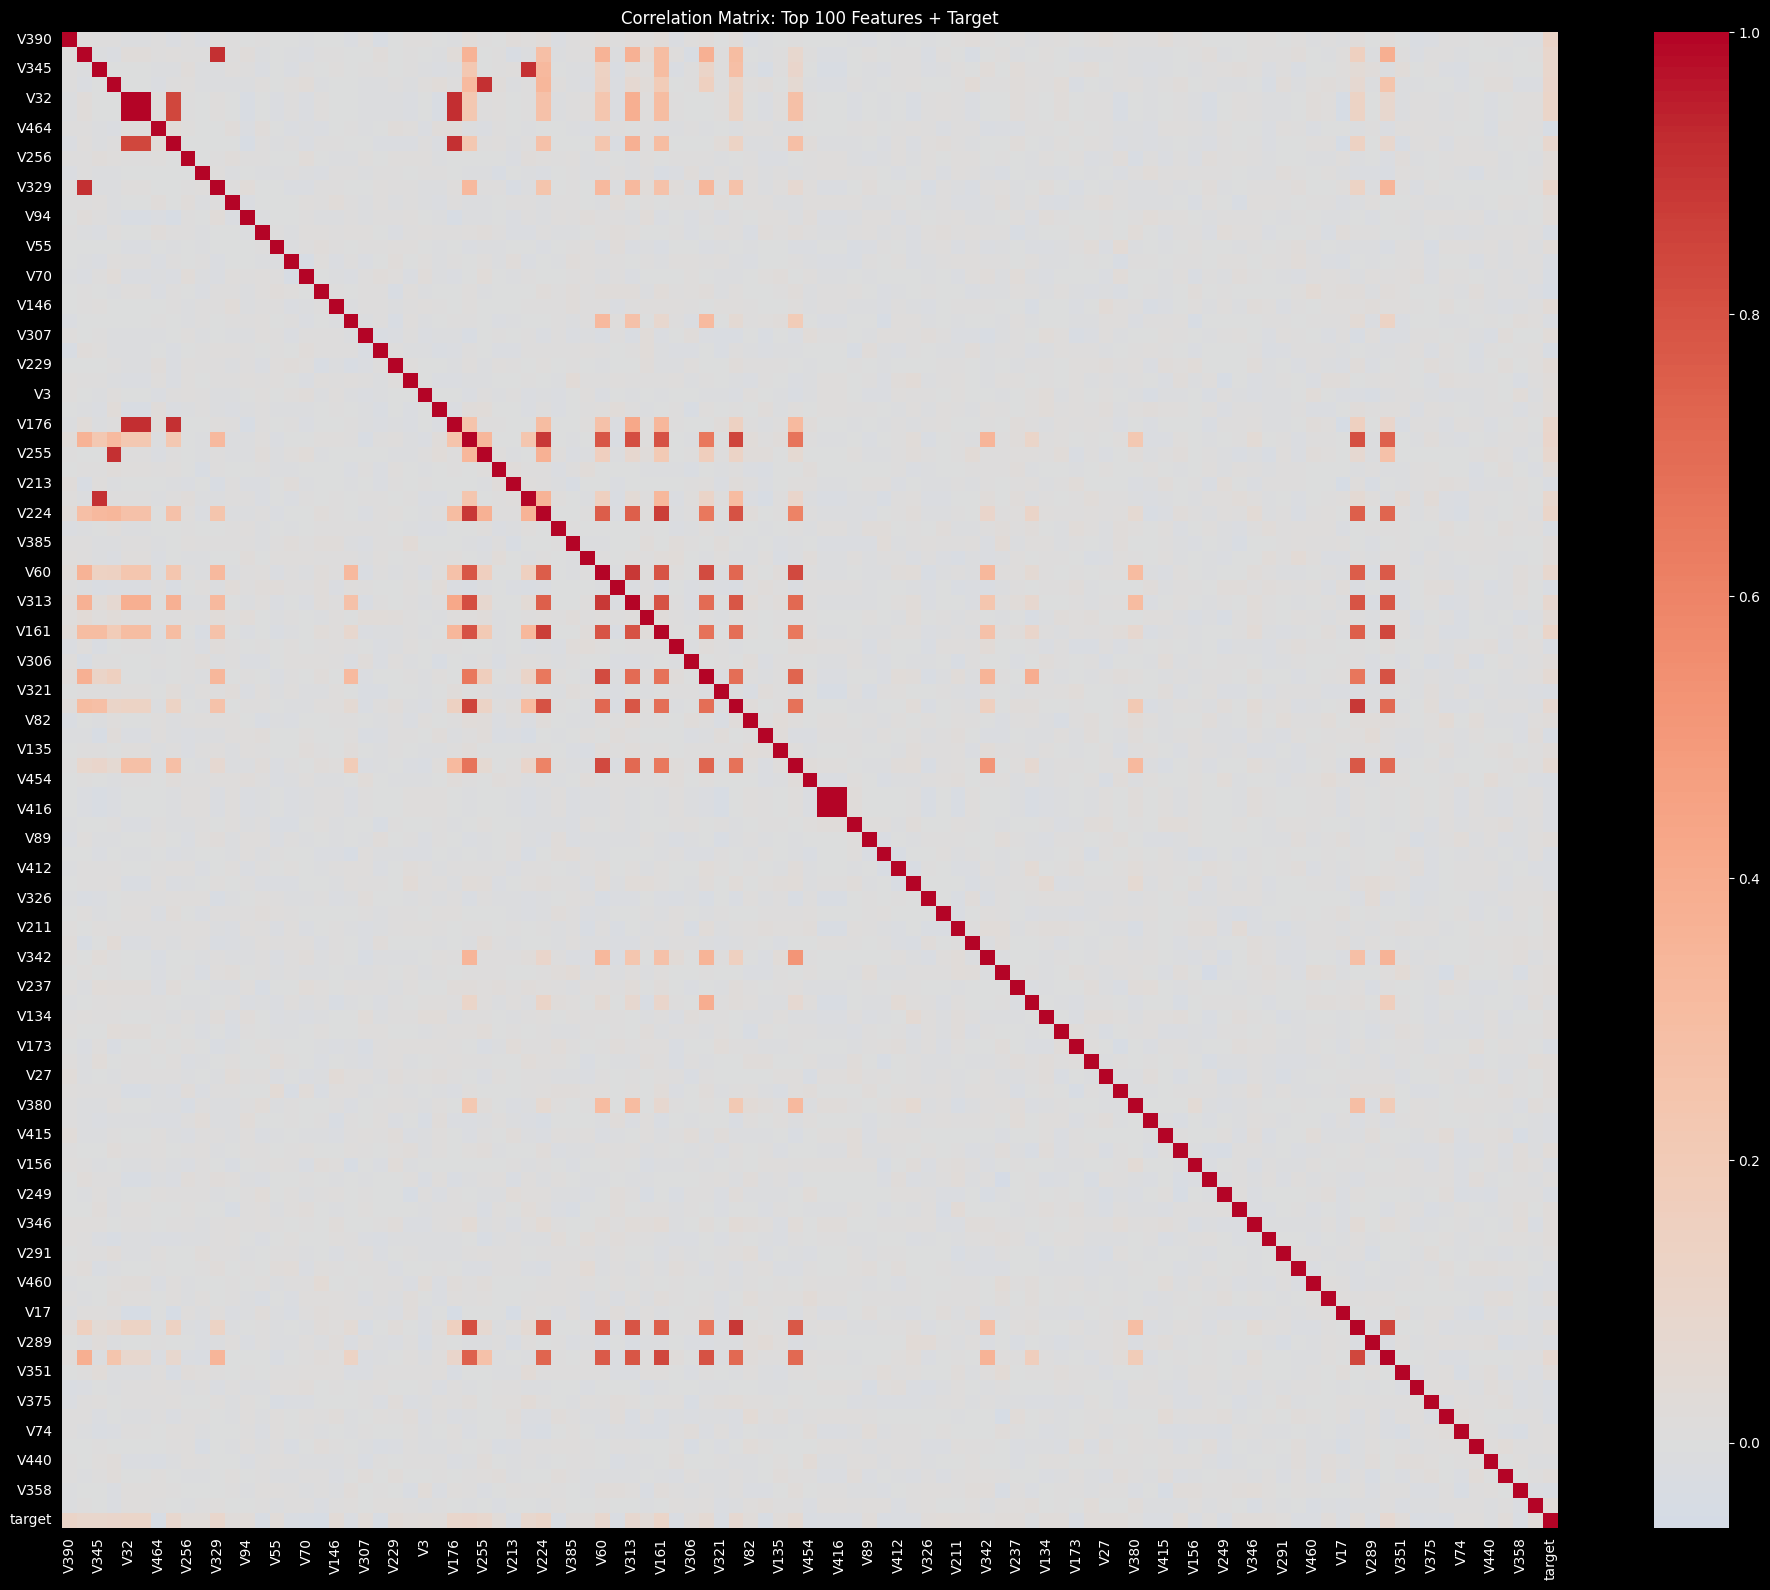

In [5]:
top_100_features = (
    feature_importance_df
    .sort_values("avg_normalized_rank")
    .head(100)["feature"]
    .tolist()
)

X_top100 = x_train_scaled[top_100_features]

corr_df = X_top100.copy()
corr_df["target"] = y_train.values

corr_matrix = corr_df.corr(method="pearson")

print(corr_matrix.shape)

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix: Top 100 Features + Target")
plt.tight_layout()
plt.show()

In [6]:
feature_corr = X_top100.corr().abs()

upper = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

high_corr_pairs = (
    high_corr_pairs
    .query("correlation > 0.8")
    .sort_values("correlation", ascending=False)
)

print(high_corr_pairs.head(23))

     feature_1 feature_2  correlation
405        V32      V175     1.000000
5152      V160      V416     1.000000
426        V32      V176     0.915218
526       V175      V176     0.915218
231       V345      V191     0.912228
726       V265      V176     0.912131
110       V309      V329     0.912005
328       V199      V255     0.910321
3638       V60      V313     0.885160
4587      V443       V78     0.882532
2732       V11      V224     0.880770
3240      V224      V161     0.871000
2745       V11      V443     0.844709
4089      V161      V120     0.841759
407        V32      V265     0.835756
507       V175      V265     0.835756
8789       V78      V120     0.835258
3649       V60       V46     0.828575
3643       V60        V5     0.821362
2738       V11      V313     0.809746
2787       V11       V78     0.807639
3840      V313      V161     0.803900
3245      V224      V443     0.800274


In [7]:
threshold = 0.9

to_drop = set()

for _, row in high_corr_pairs.iterrows():
    f1, f2, corr = row["feature_1"], row["feature_2"], row["correlation"]

    if corr > threshold:
        score_f1 = feature_importance_df.loc[
            feature_importance_df["feature"] == f1,
            "avg_normalized_rank"
        ].values[0]

        score_f2 = feature_importance_df.loc[
            feature_importance_df["feature"] == f2,
            "avg_normalized_rank"
        ].values[0]

        # drop the worse feature (higher rank = worse)
        if score_f1 > score_f2:
            to_drop.add(f1)
        else:
            to_drop.add(f2)
print(to_drop)
clean_features = [
    f for f in x_train_scaled.columns
    if f not in to_drop
]

X_clean = x_train_scaled[clean_features]

{'V329', 'V191', 'V176', 'V416', 'V255', 'V175'}


### Sequential feature selection

In [8]:
all_results = []

MODEL_CONFIGS = {
    "tree": lambda C: DecisionTreeClassifier(
        max_depth=C, random_state=42
    ),

    # "rf": lambda C: RandomForestClassifier(
    #     n_estimators=200,
    #     max_depth=C,
    #     random_state=42,
    #     n_jobs=-1
    # ),
    #
    # "extra": lambda C: ExtraTreesClassifier(
    #     n_estimators=200,
    #     max_depth=C,
    #     random_state=42,
    #     n_jobs=-1
    # ),
}
C_VALUES = [3, 5, 10]
K_VALUES = range(1, 21)

TOP_N_VALUES = [50, 100, 250, 500, 750, 900, 950, 1000]
all_results = []


def competition_profit(estimator, X, y):
    scores = estimator.predict_proba(X)[:, 1]

    n_select = int(len(X) * 0.2)

    top_idx = np.argsort(scores)[::-1][:n_select]

    preds = np.zeros(len(y), dtype=int)
    preds[top_idx] = 1

    tp = ((y == 1) & (preds == 1)).sum()
    fp = ((y == 0) & (preds == 1)).sum()

    return tp * 10 - fp * 5


for model_name, model_fn in MODEL_CONFIGS.items():

    print(f"\nRunning model: {model_name}")

    for C in C_VALUES:

        print(f"  Depth/Complexity C={C}")
        base_model = model_fn(C)
        max_k = max(K_VALUES)
        print(f"    Running SFS once for max_k={max_k}")

        sfs = SequentialFeatureSelector(
            estimator=base_model,
            n_features_to_select=max_k,
            direction="forward",
            scoring=competition_profit,
            cv=5,
            n_jobs=-1
        )

        sfs.fit(x_train_scaled, y_train)
        selected_features_all = x_train_scaled.columns[sfs.get_support()].tolist()
        print(selected_features_all)

        for k in K_VALUES:

            print(f"    SFS selecting k={k}")
            selected_features = selected_features_all[:k]
            X_sel = x_train_scaled[selected_features]

            for t in TOP_N_VALUES:
                model = model_fn(C)
                summary = cross_val_eval(
                    model=model,
                    X=X_sel,
                    y=y_train,
                    n_features=k,
                    model_name=f"{model_name}_SFS_C={C}_k={k}",
                    top_n=t
                )
                summary["model_type"] = model_name
                summary["C"] = C
                summary["k"] = k
                summary["top_n"] = t
                summary["selection"] = "SFS"

                all_results.append(summary)

final_results = pd.DataFrame(all_results)


Running model: tree
  Depth/Complexity C=3
    Running SFS once for max_k=20
['V1', 'V4', 'V6', 'V9', 'V45', 'V55', 'V116', 'V128', 'V152', 'V156', 'V157', 'V176', 'V191', 'V255', 'V287', 'V288', 'V295', 'V414', 'V460', 'V466']
    SFS selecting k=1
    SFS selecting k=2
    SFS selecting k=3
    SFS selecting k=4
    SFS selecting k=5
    SFS selecting k=6
    SFS selecting k=7
    SFS selecting k=8
    SFS selecting k=9
    SFS selecting k=10
    SFS selecting k=11
    SFS selecting k=12
    SFS selecting k=13
    SFS selecting k=14
    SFS selecting k=15
    SFS selecting k=16
    SFS selecting k=17
    SFS selecting k=18
    SFS selecting k=19
    SFS selecting k=20
  Depth/Complexity C=5
    Running SFS once for max_k=20
['V12', 'V15', 'V30', 'V51', 'V91', 'V98', 'V154', 'V160', 'V198', 'V226', 'V231', 'V243', 'V255', 'V265', 'V297', 'V328', 'V368', 'V449', 'V464', 'V490']
    SFS selecting k=1
    SFS selecting k=2
    SFS selecting k=3
    SFS selecting k=4
    SFS selecting k=

In [10]:
final_results.sort_values(by="score", ascending=False)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,model_type,C,k,selection
327,0.5444,0.605000,0.243167,0.346904,815.0,615.0,1,0.006348,0.015811,0.006356,0.009066,47.434165,47.434165,tree_SFS_C=10_k=1,None,1000,tree,10,1,SFS
326,0.5440,0.609474,0.232718,0.336824,787.0,587.0,1,0.005431,0.014123,0.005415,0.007826,40.249224,40.249224,tree_SFS_C=10_k=1,None,950,tree,10,1,SFS
325,0.5432,0.613333,0.221864,0.325855,756.0,556.0,1,0.006301,0.017830,0.006395,0.009412,48.140420,48.140420,tree_SFS_C=10_k=1,None,900,tree,10,1,SFS
324,0.5392,0.622667,0.187699,0.288447,651.0,451.0,1,0.004550,0.016055,0.004735,0.007312,36.124784,36.124784,tree_SFS_C=10_k=1,None,750,tree,10,1,SFS
335,0.5300,0.569000,0.228689,0.326253,707.0,307.0,2,0.020062,0.050794,0.020308,0.029015,152.381101,152.381101,tree_SFS_C=10_k=2,None,1000,tree,10,2,SFS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,0.5108,0.710000,0.028540,0.054874,113.0,-3887.0,20,0.004764,0.108397,0.004381,0.008422,32.519225,32.519225,tree_SFS_C=3_k=20,None,100,tree,3,20,SFS
473,0.5096,0.680000,0.027329,0.052547,104.0,-3896.0,20,0.005413,0.139642,0.005607,0.010781,41.892720,41.892720,tree_SFS_C=10_k=20,None,100,tree,10,20,SFS
312,0.5084,0.800000,0.016076,0.031518,70.0,-3930.0,20,0.003507,0.187083,0.003753,0.007359,28.062430,28.062430,tree_SFS_C=5_k=20,None,50,tree,5,20,SFS
152,0.5072,0.740000,0.014873,0.029160,61.0,-3939.0,20,0.003114,0.134164,0.002709,0.005310,20.124612,20.124612,tree_SFS_C=3_k=20,None,50,tree,3,20,SFS


### Analysis of 1 feature models for all features

In [ ]:
TOP_FEATURES = 50

top_features = (
    feature_importance_df
    .sort_values("avg_normalized_rank")
    .head(TOP_FEATURES)["feature"]
    .tolist()
)

MODEL_CONFIGS = {
    "tree": lambda C: DecisionTreeClassifier(
        max_depth=C, random_state=42
    ),

    "rf": lambda C: RandomForestClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),

    "extra": lambda C: ExtraTreesClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),
    "LogisticRegression": lambda C: LogisticRegression(
        max_iter=10000, C=C
    )
}

TOP_N_VALUES = [50, 100, 250, 500, 1000]
C_VALUES = [3, 5, 10]
results = []

i = 1
for feature in top_features:
    print(i)
    i += 1
    X = x_train_scaled[[feature]]

    for model_name, model_fn in MODEL_CONFIGS.items():

        for C in C_VALUES:

            model = model_fn(C)

            for t in TOP_N_VALUES:
                summary = cross_val_eval(
                    model=model,
                    X=X,
                    y=y_train,
                    n_features=1,
                    top_n=t,
                    model_name=f"{model_name}_C={C}_feature={feature}"
                )

                summary["feature"] = feature
                summary["C"] = C
                summary["top_n"] = t

                results.append(summary)


1
2


In [28]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="score", ascending=False).head(10)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,feature,C
1689,0.5568,0.636,0.255633,0.364685,908.0,708.0,1,0.011032,0.026786,0.010934,0.015529,80.358571,80.358571,tree_C=5_feature=V255,None,1000,V255,5
1699,0.5560,0.634,0.254830,0.363539,902.0,702.0,1,0.016598,0.040835,0.016562,0.023566,122.505102,122.505102,rf_C=3_feature=V255,None,1000,V255,3
1719,0.5552,0.632,0.254024,0.362390,896.0,696.0,1,0.013217,0.032519,0.013187,0.018764,97.557675,97.557675,extra_C=5_feature=V255,None,1000,V255,5
1884,0.5548,0.631,0.253617,0.361812,893.0,693.0,1,0.007791,0.019494,0.007823,0.011164,58.480766,58.480766,rf_C=5_feature=V191,None,1000,V191,5
1879,0.5544,0.630,0.253214,0.361237,890.0,690.0,1,0.010015,0.025249,0.010097,0.014425,75.746287,75.746287,rf_C=3_feature=V191,None,1000,V191,3
1684,0.5540,0.629,0.252824,0.360676,887.0,687.0,1,0.019887,0.048913,0.019831,0.028220,146.739565,146.739565,tree_C=3_feature=V255,None,1000,V255,3
1594,0.5540,0.629,0.252801,0.360652,887.0,687.0,1,0.017073,0.043789,0.017383,0.024887,131.367804,131.367804,extra_C=3_feature=V176,None,1000,V176,3
1599,0.5532,0.627,0.251998,0.359506,881.0,681.0,1,0.016084,0.041322,0.016391,0.023473,123.965721,123.965721,extra_C=5_feature=V176,None,1000,V176,5
1704,0.5532,0.627,0.252015,0.359524,881.0,681.0,1,0.013554,0.033279,0.013505,0.019213,99.837368,99.837368,rf_C=5_feature=V255,None,1000,V255,5
1894,0.5532,0.627,0.252005,0.359514,881.0,681.0,1,0.014132,0.035812,0.014288,0.020426,107.436027,107.436027,extra_C=3_feature=V191,None,1000,V191,3
